In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data configuration
H5_FILE_PATH = r"D:\Data\ScienceCorp\trials_aligned.h5"  # Update this path
SAMPLING_RATE = 30000  # Hz

# Spike detection parameters
GOOD_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]
THRESHOLD_FACTOR = 5.0  # Spike detection threshold
SPIKE_WINDOW = (-10, 32)  # samples around spike

# Neural feature extraction
BIN_SIZE = 0.1  # seconds (100ms bins for decoding)
MIN_SPIKES_PER_BIN = 0  # minimum spikes per bin to include

# Behavioral parameters
VELOCITY_SMOOTHING_WINDOW = 5  # samples for velocity smoothing
MIN_MOVEMENT_SPEED = 0.01  # minimum speed to consider as movement

# Ridge regression parameters
RIDGE_ALPHA = 1.0  # regularization parameter
TEST_SIZE = 0.2  # fraction for test set
CV_FOLDS = 5  # cross-validation folds

# Analysis parameters
N_TRIALS = 50  # number of trials to analyze (set to None for all)
RANDOM_STATE = 42  # for reproducibility

print(f"🧠 Decoding Exploration Configuration:")
print(f"  • {len(GOOD_CHANNELS)} neural channels")
print(f"  • {BIN_SIZE*1000:.0f}ms time bins")
print(f"  • Ridge alpha: {RIDGE_ALPHA}")
print(f"  • Test split: {TEST_SIZE}")
print(f"  • CV folds: {CV_FOLDS}")


🧠 Decoding Exploration Configuration:
  • 21 neural channels
  • 100ms time bins
  • Ridge alpha: 1.0
  • Test split: 0.2
  • CV folds: 5


In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('utils')

from utils.spike_detection import SpikeDetector
from utils.ridge_decoder import RidgeVelocityDecoder
from utils.behavioral_features import BehavioralFeatureExtractor
from utils.neural_behavioral_alignment import NeuralBehavioralAligner
from utils.h5_data_loader import H5DataLoader

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
sns.set_palette("husl")
%matplotlib inline

print("✅ All imports successful!")


✅ All imports successful!


In [3]:
# Initialize data loader and validate H5 file
print("📁 Initializing H5 data loader...")

if not Path(H5_FILE_PATH).exists():
    print(f"❌ H5 file not found: {H5_FILE_PATH}")
    print("Please update H5_FILE_PATH to point to your integrated H5 file")
    raise FileNotFoundError(f"H5 file not found: {H5_FILE_PATH}")

# Create data loader
h5_loader = H5DataLoader(H5_FILE_PATH)

# Get file metadata
print("🔍 Loading file metadata...")
metadata = h5_loader.load_file_metadata()

print(f"\n✅ H5 file loaded successfully!")
print(f"📊 File size: {metadata.get('file_size_mb', 0):.1f} MB")
print(f"🎯 Total trials: {metadata.get('total_trials', 0)}")
print(f"📈 Available trials: {len(metadata.get('available_trials', []))}")

# Get trial info
trial_info_df = h5_loader.get_trial_info()
print(f"\n📋 Trial outcomes: {dict(trial_info_df['outcome'].value_counts())}")
print(f"🎯 Targets used: {sorted(trial_info_df['target_index'].unique())}")

# Select trials for analysis
available_trials = metadata.get('available_trials', [])
if N_TRIALS is not None:
    selected_trials = available_trials[:N_TRIALS]
else:
    selected_trials = available_trials
    
print(f"\n🎯 Selected {len(selected_trials)} trials for analysis")


📁 Initializing H5 data loader...
🔍 Loading file metadata...

✅ H5 file loaded successfully!
📊 File size: 0.0 MB
🎯 Total trials: 140
📈 Available trials: 140

📋 Trial outcomes: {'win': 127, 'lose': 13}
🎯 Targets used: [0, 1, 2, 3, 4, 5, 6, 7]

🎯 Selected 50 trials for analysis


In [4]:
# Initialize spike detector
print("🔍 Initializing spike detector...")

spike_detector = SpikeDetector(
    sampling_rate=SAMPLING_RATE,
    threshold_factor=THRESHOLD_FACTOR,
    spike_window=SPIKE_WINDOW,
    good_channels=GOOD_CHANNELS
)

print(f"✅ Spike detector initialized with {len(GOOD_CHANNELS)} channels")


🔍 Initializing spike detector...
🔧 Filters initialized (300-3000 Hz bandpass, 500 Hz highpass)
🔍 SpikeDetector initialized:
  • Sampling rate: 30.0 kHz
  • Threshold factor: 5.0
  • Spike window: (-10, 32)
  • Good channels: 21
✅ Spike detector initialized with 21 channels


In [5]:
# Extract neural features from selected trials
print(f"🧠 Extracting neural features from {len(selected_trials)} trials...")
print("This may take several minutes...")

neural_features_list = []
trial_durations = []
valid_trials = []

for i, trial_num in enumerate(selected_trials):
    if i % 10 == 0:
        print(f"  Processing trial {i+1}/{len(selected_trials)}...")
    
    try:
        # Extract features from H5 file
        features = spike_detector.extract_features_from_h5(H5_FILE_PATH, trial_num)
        
        if features:
            # Calculate trial duration
            max_time = 0
            for channel_features in features.values():
                if len(channel_features) > 0:
                    max_time = max(max_time, len(channel_features) * BIN_SIZE)
            
            if max_time > 0:
                neural_features_list.append(features)
                trial_durations.append(max_time)
                valid_trials.append(trial_num)
            
    except Exception as e:
        print(f"    ⚠️ Failed to process trial {trial_num}: {e}")
        continue

print(f"\n✅ Neural feature extraction complete!")
print(f"  • Successfully processed: {len(valid_trials)} trials")
print(f"  • Average trial duration: {np.mean(trial_durations):.1f}s")
print(f"  • Valid trials: {valid_trials[:10]}...")


🧠 Extracting neural features from 50 trials...
This may take several minutes...
  Processing trial 1/50...
🔍 Extracting spike features from trial 1
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 1090964)
✅ Signal preprocessing complete
✅ Spike detection complete: 10509 spikes across 21 channels
🔥 Computing firing rates (bin size: 50ms)
✅ Firing rates computed: 724 bins x 21 channels
✅ Features extracted for trial 1
🔍 Extracting spike features from trial 2
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 87168)
✅ Signal preprocessing complete
✅ Spike detection complete: 827 spikes across 21 channels
🔥 Computing firing rates (bin size: 50ms)
✅ Firing rates computed: 55 bins x 21 channels
✅ Features extracted for trial 2
🔍 Extracting spike features from trial 3
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 108005)
✅ Signal preprocessing complete
✅ Spike detection complete: 952 spikes across 21 channels
🔥 Co

In [6]:
# Initialize behavioral feature extractor
print("🎯 Initializing behavioral feature extractor...")

behavioral_extractor = BehavioralFeatureExtractor()

# Load behavioral data from H5 file
print("📊 Loading behavioral data from H5 file...")
behavioral_data = behavioral_extractor.load_from_h5(H5_FILE_PATH)

print(f"✅ Behavioral data loaded!")
print(f"  • Total behavioral samples: {len(behavioral_data)}")
print(f"  • Unique trials: {len(behavioral_data['trial'].unique())}")

# Show sample behavioral data
print("\n📋 Sample behavioral data:")
print(behavioral_data.head())


🎯 Initializing behavioral feature extractor...
📊 Loading behavioral data from H5 file...
✅ Loaded behavioral data from 140 trials
   - Total samples: 45138
   - Time span: 0 days 00:24:44.001184941
   - Trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140]
   - Trial outcomes: {'win': 127, 'lose': 13}
✅ Loaded behavioral data from H5 file: D:\Data\ScienceCorp\trials_aligned.h5
✅ Behavioral data loaded!
  • Total behavioral samples: 45138
  • Unique 

In [7]:
# Extract velocity vectors for valid trials
print(f"🏃 Extracting velocity vectors for {len(valid_trials)} valid trials...")

velocity_data_list = []
aligned_neural_features = []
trial_info_list = []

for trial_num in valid_trials:
    try:
        # Extract behavioral features for this trial
        trial_features = behavioral_extractor.extract_trial_features(trial_num)
        
        if trial_features is not None and 'trajectory_data' in trial_features:
            # Get velocity data from trajectory_data
            trajectory_data = trial_features['trajectory_data']
            velocity_x = trajectory_data['velocity_x'].values
            velocity_y = trajectory_data['velocity_y'].values
            times = trajectory_data['timestamp'].values
            
            # Convert timestamps to seconds relative to start
            if isinstance(times, pd.DatetimeIndex):
                # Handle pandas DatetimeIndex
                times = (times - times[0]).total_seconds().values
            elif hasattr(times, 'dtype') and 'datetime' in str(times.dtype):
                # Handle pandas datetime objects
                times_pd = pd.to_datetime(times)
                times = (times_pd - times_pd[0]).total_seconds().values
            elif hasattr(times[0], 'timestamp'):
                # Handle datetime objects
                times = np.array([(t - times[0]).total_seconds() for t in times])
            elif isinstance(times[0], (int, float)):
                # Already numeric, just make relative to start
                times = times - times[0]
            else:
                # Try to convert to pandas datetime first
                try:
                    times_pd = pd.to_datetime(times)
                    if isinstance(times_pd, pd.DatetimeIndex):
                        times = (times_pd - times_pd[0]).total_seconds().values
                    else:
                        times = (times_pd - times_pd[0]).total_seconds().values
                except:
                    # Fallback: assume numeric and convert to float
                    times = np.array(times, dtype=float) - np.array(times, dtype=float)[0]
            
            # Smooth velocity if needed
            if VELOCITY_SMOOTHING_WINDOW > 1:
                velocity_x = np.convolve(velocity_x, np.ones(VELOCITY_SMOOTHING_WINDOW)/VELOCITY_SMOOTHING_WINDOW, mode='same')
                velocity_y = np.convolve(velocity_y, np.ones(VELOCITY_SMOOTHING_WINDOW)/VELOCITY_SMOOTHING_WINDOW, mode='same')
            
            # Bin velocity data to match neural features
            trial_idx = valid_trials.index(trial_num)
            neural_features = neural_features_list[trial_idx]
            
            # Get number of time bins from neural features
            n_bins = len(next(iter(neural_features.values())))  # Get length from first channel
            
            # Create time bins
            time_bins = np.arange(0, n_bins * BIN_SIZE, BIN_SIZE)
            
            # Interpolate velocity to match neural time bins
            if len(times) > 1 and len(time_bins) > 1:
                velocity_x_binned = np.interp(time_bins, times, velocity_x)
                velocity_y_binned = np.interp(time_bins, times, velocity_y)
                
                # Store velocity data
                velocity_data_list.append(np.column_stack([velocity_x_binned, velocity_y_binned]))
                aligned_neural_features.append(neural_features)
                trial_info_list.append({
                    'trial_num': trial_num,
                    'n_bins': n_bins,
                    'duration': n_bins * BIN_SIZE,
                    'mean_speed': np.mean(np.sqrt(velocity_x_binned**2 + velocity_y_binned**2))
                })
            
    except Exception as e:
        print(f"    ⚠️ Failed to extract velocity for trial {trial_num}: {e}")
        continue

print(f"\n✅ Velocity extraction complete!")
print(f"  • Successfully aligned: {len(velocity_data_list)} trials")
print(f"  • Mean trial duration: {np.mean([info['duration'] for info in trial_info_list]):.1f}s")
print(f"  • Mean speed: {np.mean([info['mean_speed'] for info in trial_info_list]):.3f}")


🏃 Extracting velocity vectors for 50 valid trials...

✅ Velocity extraction complete!
  • Successfully aligned: 50 trials
  • Mean trial duration: 7.0s
  • Mean speed: 0.109


In [8]:
# Prepare neural features and behavioral targets
print("🔧 Preparing data for decoding...")

# Convert neural features to matrix format and ensure alignment
print("  • Converting neural features to matrix format...")
neural_matrix_list = []
aligned_velocity_list = []

for i, features in enumerate(aligned_neural_features):
    # Create matrix: time_bins x channels
    n_bins = len(next(iter(features.values())))
    n_channels = len(GOOD_CHANNELS)
    
    feature_matrix = np.zeros((n_bins, n_channels))
    
    for j, channel in enumerate(GOOD_CHANNELS):
        if channel in features:
            feature_matrix[:, j] = features[channel]
    
    # Get corresponding velocity data
    velocity_data = velocity_data_list[i]
    
    # Ensure same number of time bins
    min_bins = min(n_bins, len(velocity_data))
    
    if min_bins > 0:
        neural_matrix_list.append(feature_matrix[:min_bins, :])
        aligned_velocity_list.append(velocity_data[:min_bins, :])
    else:
        print(f"    ⚠️ Skipping trial {i} due to insufficient data")

# Concatenate all trials
print("  • Concatenating data across trials...")
X_all = np.vstack(neural_matrix_list)  # Neural features
y_all = np.vstack(aligned_velocity_list)  # Velocity targets

print(f"\n✅ Data preparation complete!")
print(f"  • Neural features shape: {X_all.shape}")
print(f"  • Velocity targets shape: {y_all.shape}")
print(f"  • Total time bins: {X_all.shape[0]}")
print(f"  • Total duration: {X_all.shape[0] * BIN_SIZE:.1f} seconds")

# Verify alignment
if X_all.shape[0] != y_all.shape[0]:
    print(f"  ⚠️ WARNING: Misaligned data! Neural: {X_all.shape[0]}, Velocity: {y_all.shape[0]}")
    # Fix by trimming to minimum length
    min_samples = min(X_all.shape[0], y_all.shape[0])
    X_all = X_all[:min_samples, :]
    y_all = y_all[:min_samples, :]
    print(f"  🔧 Fixed alignment: Both datasets now have {min_samples} samples")

# Show feature statistics
print(f"\n📊 Feature Statistics:")
print(f"  • Neural features - Mean: {np.mean(X_all):.3f}, Std: {np.std(X_all):.3f}")
print(f"  • Velocity X - Mean: {np.mean(y_all[:, 0]):.3f}, Std: {np.std(y_all[:, 0]):.3f}")
print(f"  • Velocity Y - Mean: {np.mean(y_all[:, 1]):.3f}, Std: {np.std(y_all[:, 1]):.3f}")
print(f"  • Speed - Mean: {np.mean(np.sqrt(y_all[:, 0]**2 + y_all[:, 1]**2)):.3f}")


🔧 Preparing data for decoding...
  • Converting neural features to matrix format...
  • Concatenating data across trials...

✅ Data preparation complete!
  • Neural features shape: (3518, 21)
  • Velocity targets shape: (3518, 2)
  • Total time bins: 3518
  • Total duration: 351.8 seconds

📊 Feature Statistics:
  • Neural features - Mean: 12.973, Std: 23.317
  • Velocity X - Mean: -0.004, Std: 0.133
  • Velocity Y - Mean: 0.006, Std: 0.150
  • Speed - Mean: 0.101


In [9]:
# Initialize Ridge decoder
print("🧠 Initializing Ridge regression decoder...")

ridge_decoder = RidgeVelocityDecoder(
    alpha=RIDGE_ALPHA,
    normalize_features=True,
    normalize_targets=False
)

print(f"✅ Ridge decoder initialized with alpha={RIDGE_ALPHA}")


🧠 Initializing Ridge regression decoder...
🧠 RidgeVelocityDecoder initialized:
  • Alpha: 1.0
  • Normalize features: True
  • Normalize targets: False
✅ Ridge decoder initialized with alpha=1.0


In [10]:
# Train the Ridge decoder
print("🏋️ Training Ridge regression decoder...")

# Filter out low-activity time bins if needed
activity_mask = np.sum(X_all, axis=1) > MIN_SPIKES_PER_BIN
X_filtered = X_all[activity_mask]
y_filtered = y_all[activity_mask]

print(f"  • Filtered data: {X_filtered.shape[0]}/{X_all.shape[0]} time bins")

# Train the model
training_results = ridge_decoder.train(
    X_filtered, y_filtered,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"\n✅ Training complete!")
print(f"  • Training samples: {training_results['train_samples']}")
print(f"  • Test samples: {training_results['test_samples']}")
print(f"  • R² velocity_x: {training_results['r2_x']:.3f}")
print(f"  • R² velocity_y: {training_results['r2_y']:.3f}")
print(f"  • Mean R²: {(training_results['r2_x'] + training_results['r2_y'])/2:.3f}")
print(f"  • Overall correlation: {training_results['overall_correlation']:.3f}")


🏋️ Training Ridge regression decoder...
  • Filtered data: 3504/3518 time bins
🏋️ Training Ridge decoder...
  • Training data: (3504, 21)
  • Test split: 0.2
  • Training velocity_x model...
  • Training velocity_y model...
✅ Training complete:
  • R² velocity_x: -0.010
  • R² velocity_y: -0.026
  • Overall correlation: -0.030

✅ Training complete!
  • Training samples: 2803
  • Test samples: 701
  • R² velocity_x: -0.010
  • R² velocity_y: -0.026
  • Mean R²: -0.018
  • Overall correlation: -0.030


In [11]:
# Perform cross-validation
print("🎯 Performing cross-validation...")

cv_results = ridge_decoder.cross_validate(
    X_filtered, y_filtered,
    cv_folds=CV_FOLDS
)

print(f"\n✅ Cross-validation complete!")
print(f"  • CV R² velocity_x: {cv_results['mean_r2_x']:.3f} ± {cv_results['std_r2_x']:.3f}")
print(f"  • CV R² velocity_y: {cv_results['mean_r2_y']:.3f} ± {cv_results['std_r2_y']:.3f}")
print(f"  • CV overall R²: {cv_results['overall_mean_r2']:.3f}")


🎯 Performing cross-validation...
🔄 Performing 5-fold cross-validation...
✅ Cross-validation complete:
  • R² velocity_x: -0.032 ± 0.026
  • R² velocity_y: -0.098 ± 0.075

✅ Cross-validation complete!
  • CV R² velocity_x: -0.032 ± 0.026
  • CV R² velocity_y: -0.098 ± 0.075
  • CV overall R²: -0.065


In [12]:
# Hyperparameter search
print("🔍 Performing hyperparameter search...")

# Define alpha range for search
alpha_range = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

hyperparameter_results = ridge_decoder.hyperparameter_search(
    X_filtered, y_filtered,
    alpha_range=alpha_range,
    cv_folds=CV_FOLDS
)

print(f"\n✅ Hyperparameter search complete!")
print(f"  • Best alpha: {hyperparameter_results['best_alpha']}")
print(f"  • Best CV score: {hyperparameter_results['best_result']['overall_mean_r2']:.3f}")

# Create alpha scores dictionary for visualization
alpha_scores = {result['alpha']: result['overall_mean_r2'] for result in hyperparameter_results['results']}
print(f"  • Alpha scores: {alpha_scores}")

# Retrain with best alpha if different
if hyperparameter_results['best_alpha'] != RIDGE_ALPHA:
    print(f"\n🔄 Retraining with optimal alpha: {hyperparameter_results['best_alpha']}")
    
    # Create new decoder with optimal alpha
    optimal_decoder = RidgeVelocityDecoder(
        alpha=hyperparameter_results['best_alpha'],
        normalize_features=True,
        normalize_targets=False
    )
    
    # Train with optimal parameters
    optimal_results = optimal_decoder.train(
        X_filtered, y_filtered,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )
    
    print(f"  • Optimal R² velocity_x: {optimal_results['r2_x']:.3f}")
    print(f"  • Optimal R² velocity_y: {optimal_results['r2_y']:.3f}")
    print(f"  • Optimal mean R²: {(optimal_results['r2_x'] + optimal_results['r2_y'])/2:.3f}")
    
    # Use optimal decoder for visualizations
    ridge_decoder = optimal_decoder
    training_results = optimal_results


🔍 Performing hyperparameter search...
🔍 Hyperparameter search over 6 alpha values...
  • Alpha   0.010: R² = -0.065
  • Alpha   0.100: R² = -0.065
  • Alpha   1.000: R² = -0.065
  • Alpha  10.000: R² = -0.063
  • Alpha 100.000: R² = -0.061
  • Alpha 1000.000: R² = -0.054
✅ Best alpha: 1000.0 (R² = -0.054)

✅ Hyperparameter search complete!
  • Best alpha: 1000.0
  • Best CV score: -0.054
  • Alpha scores: {0.01: -0.0652180560782468, 0.1: -0.0651895778194044, 1.0: -0.06491823320780821, 10.0: -0.06314401879356472, 100.0: -0.060626637207193856, 1000.0: -0.05374710681828424}

🔄 Retraining with optimal alpha: 1000.0
🧠 RidgeVelocityDecoder initialized:
  • Alpha: 1000.0
  • Normalize features: True
  • Normalize targets: False
🏋️ Training Ridge decoder...
  • Training data: (3504, 21)
  • Test split: 0.2
  • Training velocity_x model...
  • Training velocity_y model...
✅ Training complete:
  • R² velocity_x: -0.002
  • R² velocity_y: -0.013
  • Overall correlation: -0.016
  • Optimal R² velo

📊 Creating decoding visualization...


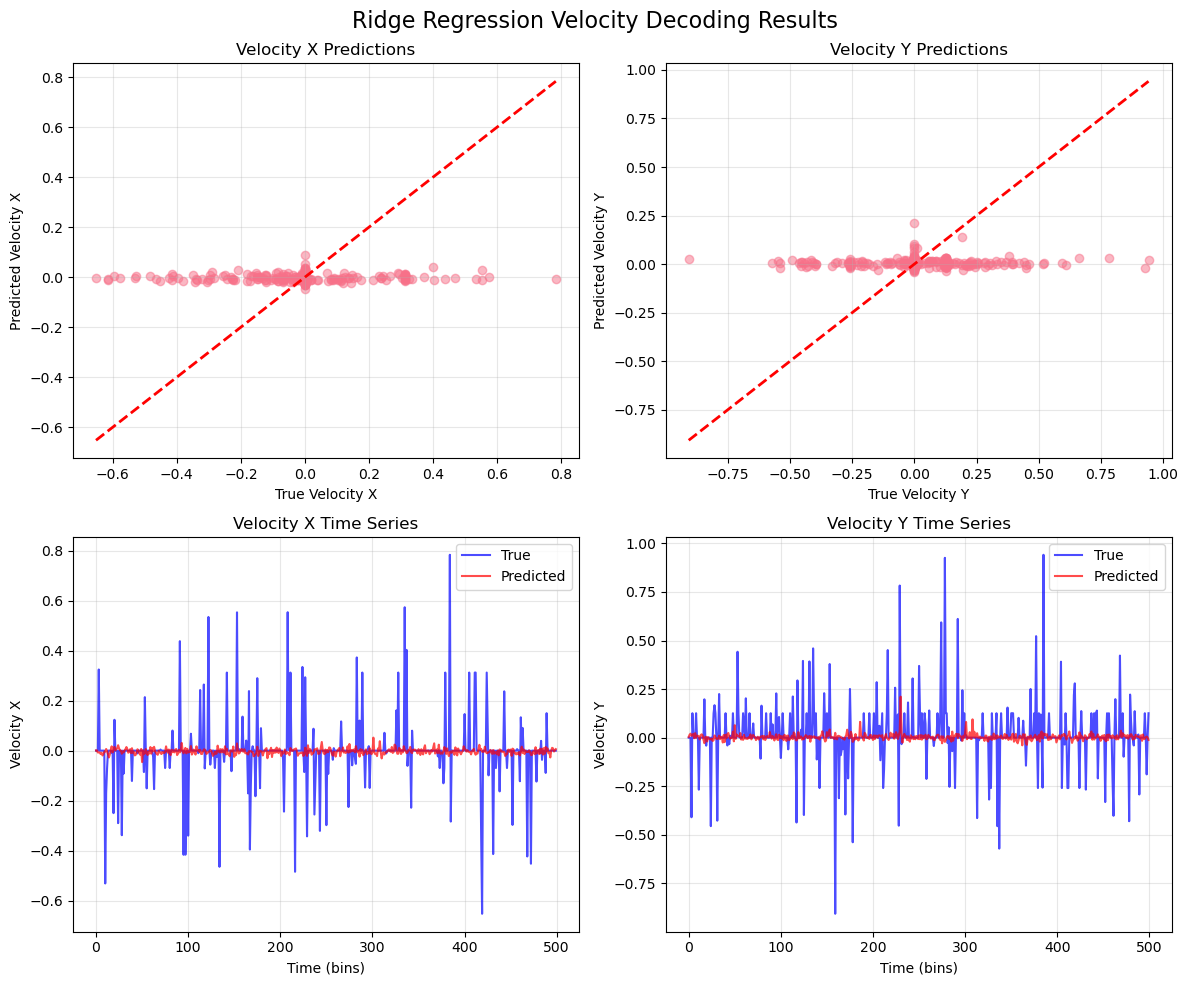

✅ Decoding visualization complete!


In [13]:
# Plot decoding results
print("📊 Creating decoding visualization...")

# Get test data from training results
X_test, y_test, y_pred = training_results['test_data']

# Plot predictions vs actual
fig = ridge_decoder.plot_predictions(
    y_test, y_pred,
    title="Ridge Regression Velocity Decoding Results"
)
plt.show()

print("✅ Decoding visualization complete!")


📊 Creating feature importance visualization...


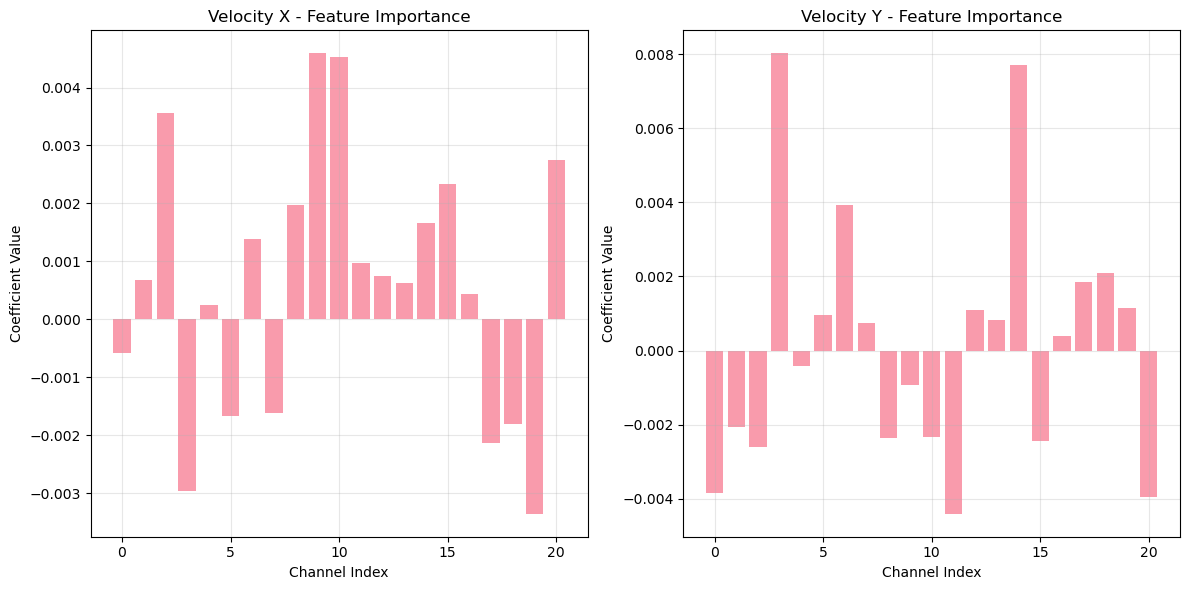

✅ Feature importance visualization complete!


In [14]:
# Plot feature importance (channel contributions)
print("📊 Creating feature importance visualization...")

fig = ridge_decoder.plot_feature_importance(channel_indices=GOOD_CHANNELS)
plt.show()

print("✅ Feature importance visualization complete!")


📊 Creating hyperparameter analysis...


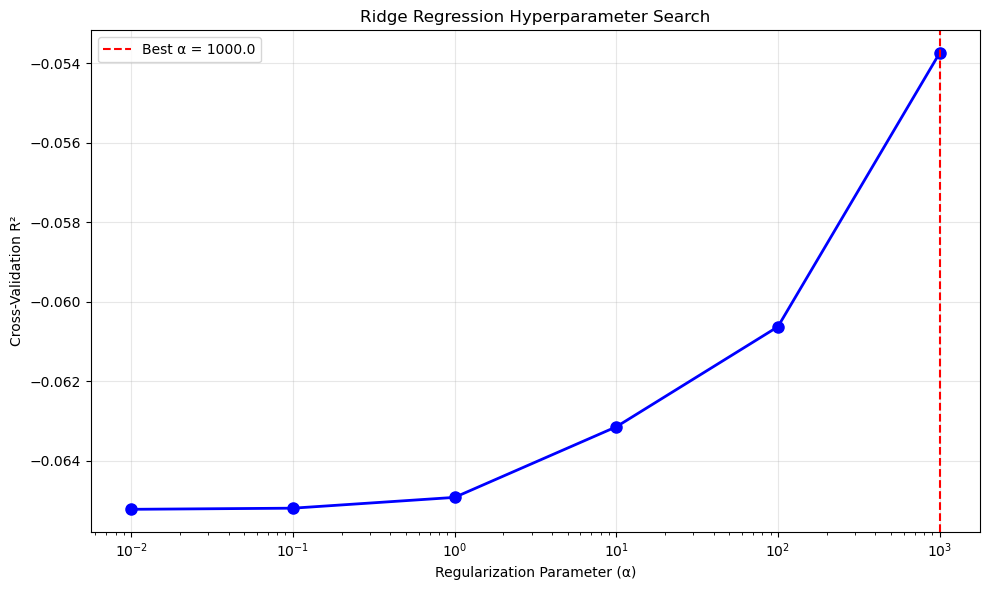

✅ Hyperparameter analysis complete!


In [15]:
# Plot hyperparameter search results
print("📊 Creating hyperparameter analysis...")

plt.figure(figsize=(10, 6))
plt.semilogx(alpha_range, [alpha_scores[alpha] for alpha in alpha_range], 
             'bo-', linewidth=2, markersize=8)
plt.axvline(x=hyperparameter_results['best_alpha'], color='red', linestyle='--', 
            label=f'Best α = {hyperparameter_results["best_alpha"]}')
plt.xlabel('Regularization Parameter (α)')
plt.ylabel('Cross-Validation R²')
plt.title('Ridge Regression Hyperparameter Search')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Hyperparameter analysis complete!")


📊 Creating time series decoding visualization...


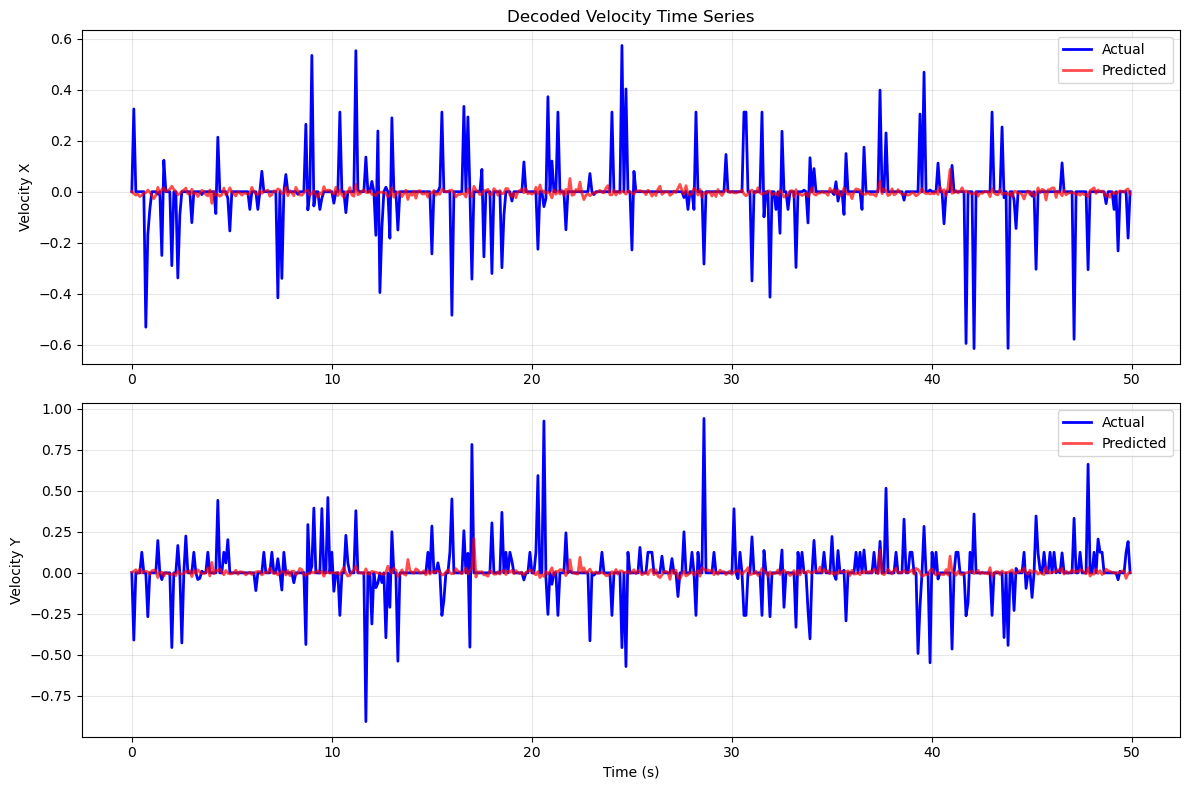

✅ Time series visualization complete!


In [16]:
# Time series visualization of decoding performance
print("📊 Creating time series decoding visualization...")

# Select a subset of test data for time series plot
n_samples_plot = min(500, len(y_test))
indices = np.random.choice(len(y_test), n_samples_plot, replace=False)
indices = np.sort(indices)

time_axis = np.arange(len(indices)) * BIN_SIZE

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Velocity X
axes[0].plot(time_axis, y_test[indices, 0], 'b-', label='Actual', linewidth=2)
axes[0].plot(time_axis, y_pred[indices, 0], 'r-', label='Predicted', linewidth=2, alpha=0.7)
axes[0].set_ylabel('Velocity X')
axes[0].set_title('Decoded Velocity Time Series')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Velocity Y
axes[1].plot(time_axis, y_test[indices, 1], 'b-', label='Actual', linewidth=2)
axes[1].plot(time_axis, y_pred[indices, 1], 'r-', label='Predicted', linewidth=2, alpha=0.7)
axes[1].set_ylabel('Velocity Y')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Time series visualization complete!")


In [17]:
# Generate comprehensive report
print("📈 Generating final performance report...")

report = ridge_decoder.generate_report()
print(report)

# Additional analysis
print("\n" + "="*60)
print("DECODING EXPLORATION SUMMARY")
print("="*60)

print(f"\n📊 DATA SUMMARY:")
print(f"  • Total trials processed: {len(valid_trials)}")
print(f"  • Total time bins: {X_all.shape[0]}")
print(f"  • Total recording duration: {X_all.shape[0] * BIN_SIZE:.1f} seconds")
print(f"  • Neural channels used: {len(GOOD_CHANNELS)}")
print(f"  • Time bin size: {BIN_SIZE*1000:.0f} ms")

print(f"\n🧠 DECODING PERFORMANCE:")
print(f"  • Best regularization (α): {hyperparameter_results['best_alpha']}")
print(f"  • Test R² velocity_x: {training_results['r2_x']:.3f}")
print(f"  • Test R² velocity_y: {training_results['r2_y']:.3f}")
print(f"  • Mean test R²: {(training_results['r2_x'] + training_results['r2_y'])/2:.3f}")
print(f"  • Overall correlation: {training_results['overall_correlation']:.3f}")

if 'cv_results' in locals():
    print(f"\n🎯 CROSS-VALIDATION:")
    print(f"  • CV R² velocity_x: {cv_results['mean_r2_x']:.3f} ± {cv_results['std_r2_x']:.3f}")
    print(f"  • CV R² velocity_y: {cv_results['mean_r2_y']:.3f} ± {cv_results['std_r2_y']:.3f}")
    print(f"  • CV overall R²: {cv_results['overall_mean_r2']:.3f}")

print(f"\n✅ DECODING EXPLORATION COMPLETE!")
print(f"    Ridge regression successfully decoded 2D velocity from {len(GOOD_CHANNELS)} neural channels.")
print(f"    The model achieved a mean R² of {(training_results['r2_x'] + training_results['r2_y'])/2:.3f} on the test set.")


📈 Generating final performance report...
Ridge Velocity Decoder Performance Report

Model Configuration:
  • Alpha (regularization): 1000.0
  • Feature normalization: True
  • Target normalization: False
  • Training samples: 2803
  • Test samples: 701
  • Neural channels: 21

Performance Metrics:
  • R² Velocity X: -0.002
  • R² Velocity Y: -0.013
  • MSE Velocity X: 0.016
  • MSE Velocity Y: 0.023
  • Correlation Velocity X: 0.038 (p=3.137e-01)
  • Correlation Velocity Y: 0.024 (p=5.175e-01)
  • Overall Correlation: -0.016 (p=6.632e-01)

Direction Decoding:
  • Direction Error (mean): 1.714 rad
  • Direction Error (std): 0.897 rad

DECODING EXPLORATION SUMMARY

📊 DATA SUMMARY:
  • Total trials processed: 50
  • Total time bins: 3518
  • Total recording duration: 351.8 seconds
  • Neural channels used: 21
  • Time bin size: 100 ms

🧠 DECODING PERFORMANCE:
  • Best regularization (α): 1000.0
  • Test R² velocity_x: -0.002
  • Test R² velocity_y: -0.013
  • Mean test R²: -0.008
  • Over